# Formation Graphs

Visualize the canonical node-and-edge topology of each formation in
`graphs.templates.FORMATION_TEMPLATES`. Each panel shows a single
formation as a graph laid out on the pitch: 11 nodes at their template
coordinates (GK at index 0 on the far left), edges built from a fixed
set of **tactical rules** (no distance-based k-NN cut).

Tactical rules encoded in `graphs.templates._build_edges`:
1. GK ↔ every defender.
2. All CBs mutually connected; fullbacks ↔ their outer CB.
3. Every CB ↔ every CDM.
4. CDMs and CAMs ↔ every other midfielder.
5. All central midfielders (CM/CDM/CAM) mutually connected.
6. Wide mids (LM/LAM/RM/RAM) ↔ every central mid.
7. Same-side wide-mid mesh (LM ↔ LAM; RM ↔ RAM).
8. Each fullback ↔ closest same-side wide attacker; falls back to nearest same-side central mid.
9. Wingers ↔ same-side wide mids.
10. Wingers ↔ strikers and CAMs.
11. Strikers mutually connected.
12. Strikers ↔ all central mids.

Sanity checks to look for in each panel:
- Same-side full-backs / wing-backs connect to same-side wingers / wide mids, not to the opposite side.
- GK only connects to the back line; never to a midfielder.
- All CBs in a back-three are mutually connected and each connects to every CDM.
- CDM and CAM are hub-like nodes wired to every other midfielder.
- Cross-formation differences are visible (4-4-2 vs 3-5-2 should look noticeably different).

In [11]:
from __future__ import annotations
import sys
from pathlib import Path
import math

HERE = Path.cwd()
ROOT = HERE
while ROOT != ROOT.parent and not (ROOT / 'configs' / 'config.yaml').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from graphs.templates import FORMATION_TEMPLATES, formation_graph

print(f'{len(FORMATION_TEMPLATES)} formation templates registered')

17 formation templates registered


In [12]:
def draw_formation(ax, formation: str) -> None:
    nodes, edges = formation_graph(formation)
    # Pitch background -- x is depth (0=own goal, 100=opponent goal), y is lateral.
    ax.add_patch(mpatches.Rectangle((-5, -5), 115, 90, facecolor='#e6f2e6', edgecolor='gray', lw=0.5))
    # Halfway line
    ax.axvline(50, color='white', lw=1)
    # Edges first so they sit under the nodes.
    for i, j in edges:
        x1, y1 = nodes[i][1], nodes[i][2]
        x2, y2 = nodes[j][1], nodes[j][2]
        ax.plot([x1, x2], [y1, y2], color='gray', lw=1.0, alpha=0.6, zorder=1)
    # Nodes
    for idx, (label, x, y) in enumerate(nodes):
        color = '#ff9933' if label == 'GK' else '#1f78b4'
        ax.scatter(x, y, s=400, color=color, edgecolor='black', linewidth=1.0, zorder=2)
        ax.text(x, y, str(idx), ha='center', va='center', fontsize=8, color='white', zorder=3, fontweight='bold')
        ax.text(x, y - 7, label, ha='center', va='top', fontsize=7, color='black', zorder=3)
    ax.set_xlim(-5, 110); ax.set_ylim(-5, 85)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{formation}  ({len(nodes)} nodes, {len(edges)} edges)', fontsize=10)

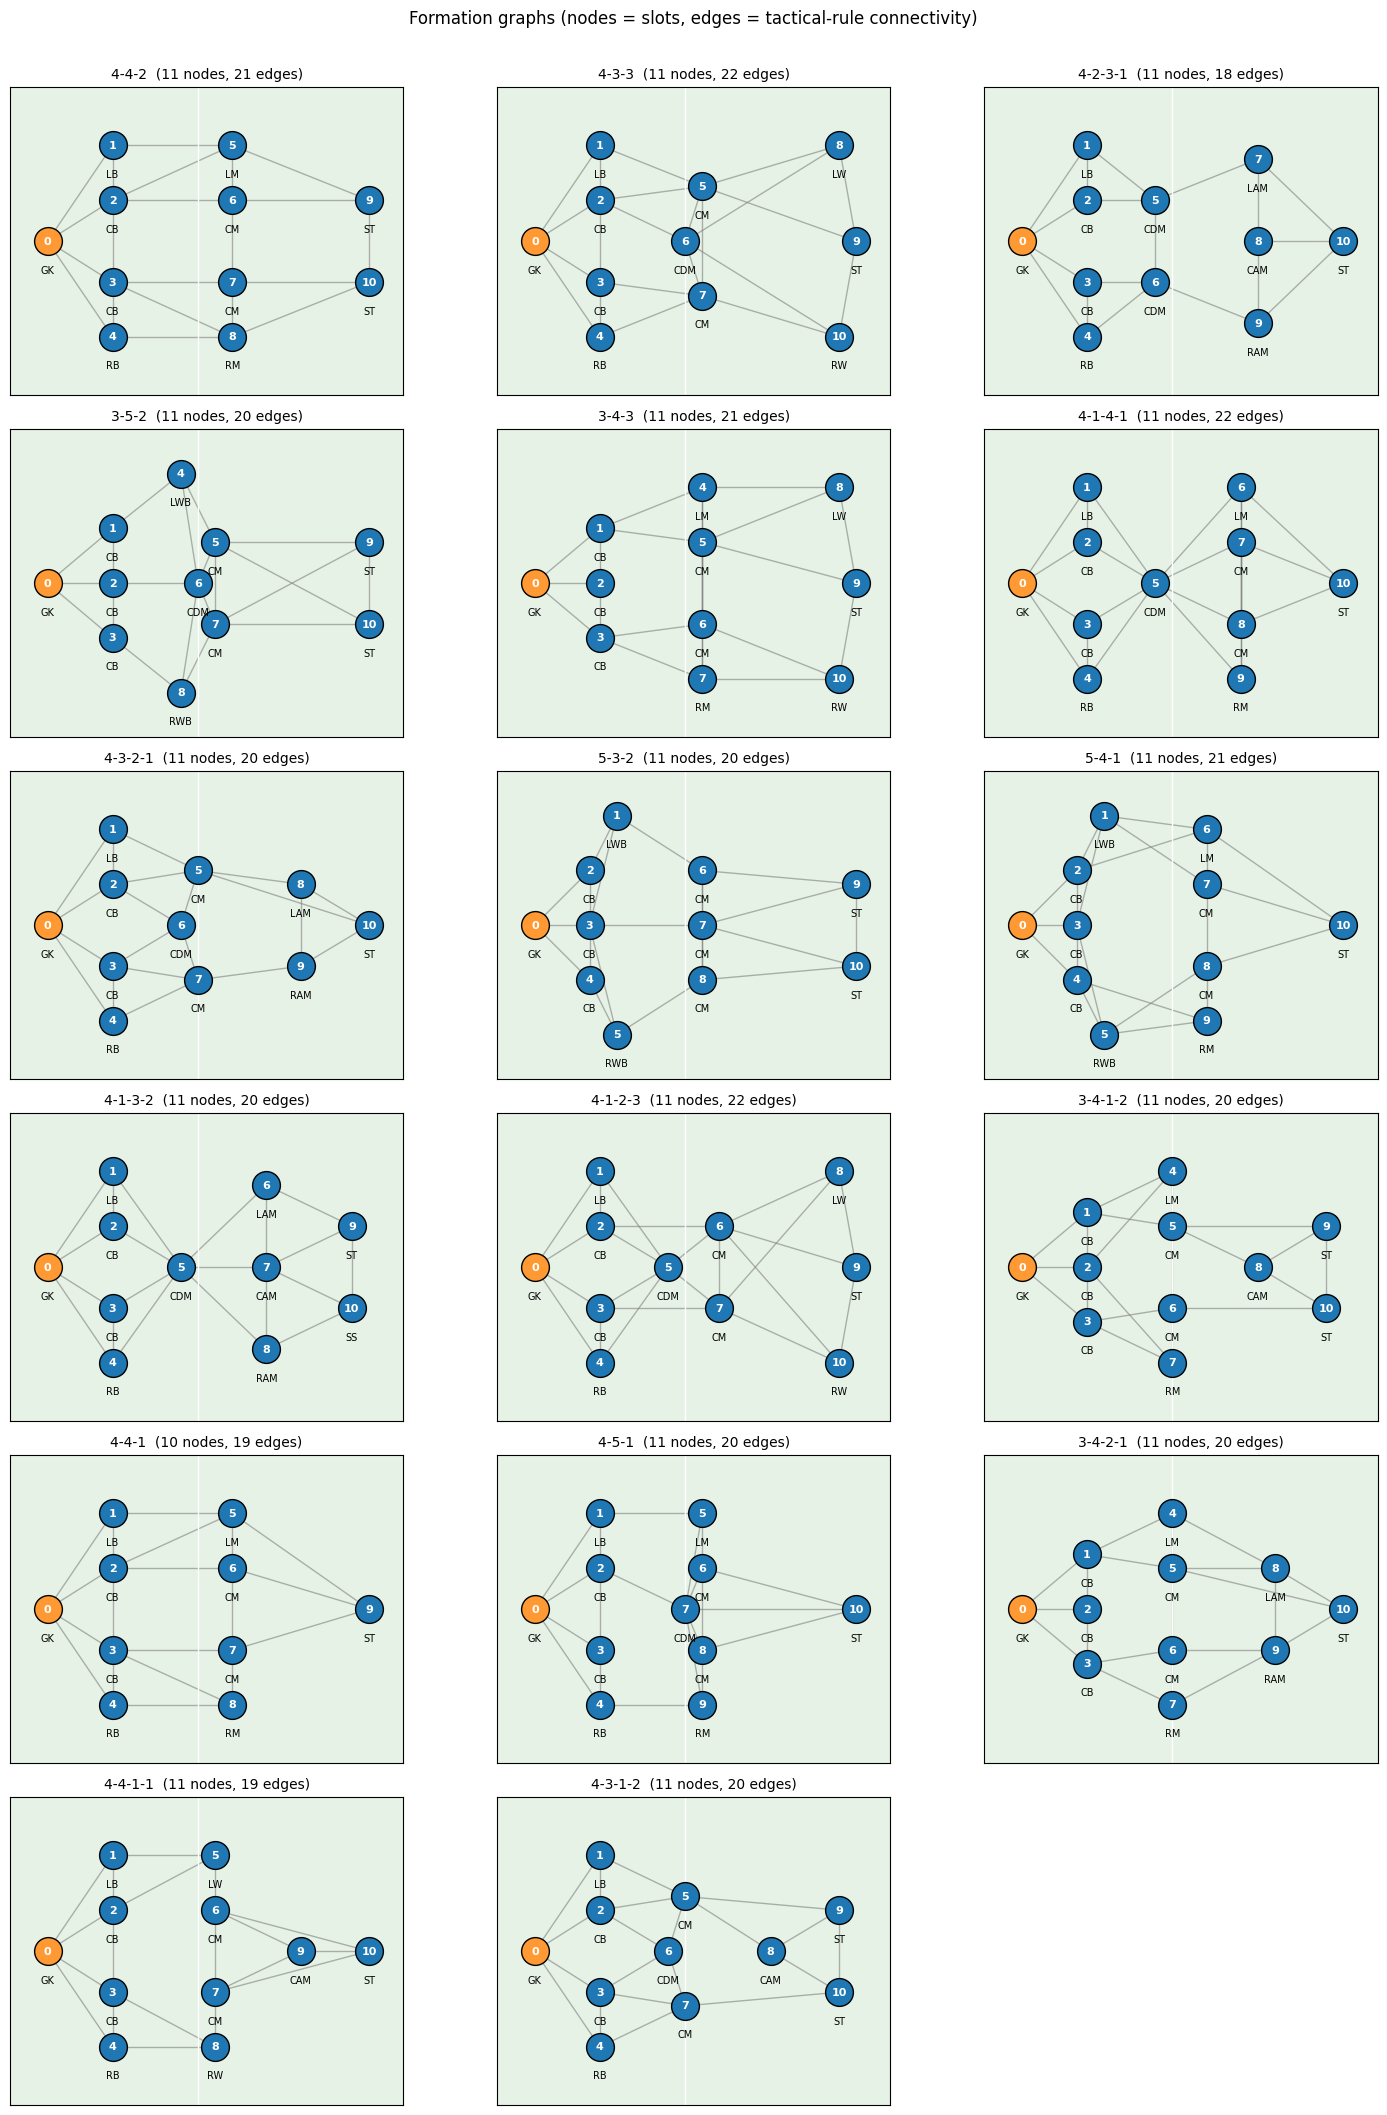

In [13]:
formations = list(FORMATION_TEMPLATES.keys())
ncols = 3
nrows = math.ceil(len(formations) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.0, nrows * 3.5))
axes = axes.flatten()
for ax in axes[len(formations):]:
    ax.set_visible(False)
for ax, f in zip(axes, formations):
    draw_formation(ax, f)
fig.suptitle('Formation graphs (nodes = slots, edges = tactical-rule connectivity)', y=1.005)
fig.tight_layout(); plt.show()

## Per-formation edge listings

For each formation, dump the edges as labeled pairs with their Euclidean
distance on the template pitch. Useful as a quick reference when
implementing the GNN feature builder.

In [14]:
for formation in formations:
    nodes, edges = formation_graph(formation)
    print(f'\n=== {formation} ({len(nodes)} nodes, {len(edges)} edges) ===')
    for i, j in edges:
        li, xi, yi = nodes[i]
        lj, xj, yj = nodes[j]
        d = math.hypot(xi - xj, yi - yj)
        print(f'  {i:>2}.{li:<4} \u2194 {j:>2}.{lj:<4}   dist={d:5.1f}')


=== 4-4-2 (11 nodes, 21 edges) ===
   0.GK   ↔  1.LB     dist= 33.8
   0.GK   ↔  2.CB     dist= 22.5
   0.GK   ↔  3.CB     dist= 22.5
   0.GK   ↔  4.RB     dist= 33.8
   1.LB   ↔  2.CB     dist= 16.0
   1.LB   ↔  5.LM     dist= 35.0
   2.CB   ↔  3.CB     dist= 24.0
   2.CB   ↔  5.LM     dist= 38.5
   2.CB   ↔  6.CM     dist= 35.0
   3.CB   ↔  4.RB     dist= 16.0
   3.CB   ↔  7.CM     dist= 35.0
   3.CB   ↔  8.RM     dist= 38.5
   4.RB   ↔  8.RM     dist= 35.0
   5.LM   ↔  6.CM     dist= 16.0
   5.LM   ↔  9.ST     dist= 43.1
   6.CM   ↔  7.CM     dist= 24.0
   6.CM   ↔  9.ST     dist= 40.0
   7.CM   ↔  8.RM     dist= 16.0
   7.CM   ↔ 10.ST     dist= 40.0
   8.RM   ↔ 10.ST     dist= 43.1
   9.ST   ↔ 10.ST     dist= 24.0

=== 4-3-3 (11 nodes, 22 edges) ===
   0.GK   ↔  1.LB     dist= 33.8
   0.GK   ↔  2.CB     dist= 22.5
   0.GK   ↔  3.CB     dist= 22.5
   0.GK   ↔  4.RB     dist= 33.8
   1.LB   ↔  2.CB     dist= 16.0
   1.LB   ↔  5.CM     dist= 32.3
   2.CB   ↔  3.CB     dist= 24.0
   2

## Degree distribution per formation

Hub-y nodes (CDM, CAM, central CBs in back-three systems) will show
higher degrees by design — they're connected to every midfielder /
defender by construction. Outer wing-backs and wide attackers will have
the lowest degrees.

In [15]:
import pandas as pd
rows = []
for f in formations:
    nodes, edges = formation_graph(f)
    deg = [0] * len(nodes)
    for i, j in edges:
        deg[i] += 1; deg[j] += 1
    rows.append({
        'formation': f, 'n_nodes': len(nodes), 'n_edges': len(edges),
        'mean_deg': sum(deg)/len(deg), 'min_deg': min(deg), 'max_deg': max(deg),
    })
pd.DataFrame(rows).set_index('formation').round(2)

,n_nodes,n_edges,mean_deg,min_deg,max_deg
formation,,,,,
4-4-2,11,21,3.82,3,5
4-3-3,11,22,4.00,3,6
4-2-3-1,11,18,3.27,3,4
3-5-2,11,20,3.64,3,5
3-4-3,11,21,3.82,3,6
4-1-4-1,11,22,4.00,3,8
4-3-2-1,11,20,3.64,3,5
5-3-2,11,20,3.64,3,6
5-4-1,11,21,3.82,3,5
